# Evaluación 2
## Programación Científica 2026-1

### Universidad Nacional de Colombia - Sede Medellín

---

## Estudiante

**Nombre:** Juan Esteban Osorno Duque

**ID de la evaluación:** 4879

---

# Introducción

En esta evaluación se estudia el problema de la reconstrucción de señales mediante una red neuronal de dos capas. El objetivo principal consiste en comparar dos estrategias para inicializar la primera capa de la red: una inicialización aleatoria y una inicialización basada en la Transformada de Fourier.

Las señales utilizadas fueron generadas a partir de distintos regímenes de dispersión y están compuestas por una combinación de funciones seno y coseno con diferentes frecuencias. Debido a esta estructura, resulta natural preguntarse si una representación basada en Fourier permite aprender de manera más eficiente que una representación completamente aleatoria.

A lo largo del desarrollo se analizarán las señales, se construirá la base de Fourier solicitada en el enunciado, se implementará la red neuronal en JAX y finalmente se comparará el desempeño de ambas inicializaciones mediante diferentes métricas y visualizaciones científicas.

---

## Objetivos

Los objetivos de esta evaluación son:

- Explorar y comprender la estructura del conjunto de datos suministrado.
- Construir una capa de Fourier utilizando \(K=30\) frecuencias.
- Implementar una red neuronal capaz de reconstruir las señales de entrada.
- Comparar el entrenamiento de una red inicializada aleatoriamente con otra inicializada mediante Fourier.
- Analizar la capacidad de compresión de las señales utilizando la energía acumulada de los coeficientes de Fourier.

---



# 1. Configuración del entorno de trabajo

Antes de comenzar con el análisis del conjunto de datos es necesario preparar el entorno de trabajo. En esta sección se importan las bibliotecas que serán utilizadas a lo largo de la evaluación y se configura un estilo uniforme para todas las visualizaciones científicas.

En particular:

- **NumPy** será utilizado para el manejo eficiente de arreglos y operaciones matriciales.
- **Matplotlib** permitirá construir las figuras necesarias para analizar las señales y los resultados del entrenamiento.
- Finalmente, se establece una configuración gráfica común que mejora la legibilidad de las figuras y proporciona soporte para expresiones matemáticas utilizando la sintaxis de LaTeX.

In [388]:
# Librerías principales
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from jax import grad
from jax import jit
from jax import random

# Configuración de las gráficas
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({

    "figure.figsize": (10,5),

    "figure.dpi": 120,

    "font.family": "serif",

    "mathtext.fontset": "cm",

    "axes.titlesize": 14,

    "axes.labelsize": 12,

    "legend.fontsize": 11,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10

})

# Nuestra semilla generadora para el paso de JAX
key = random.PRNGKey(4879)

# 2. Carga del conjunto de datos

Una vez configurado el entorno de trabajo, el siguiente paso consiste en cargar el conjunto de datos suministrado para esta evaluación.

El archivo se encuentra almacenado en formato **NumPy (.npz)**, el cual permite guardar múltiples arreglos dentro de un mismo archivo. En este caso, dicho archivo contiene las señales generadas para los tres regímenes de dispersión descritos en el enunciado, así como la información necesaria para identificarlas y analizarlas.

Antes de comenzar cualquier procesamiento, resulta conveniente inspeccionar el contenido del archivo para verificar que la carga se realizó correctamente y conocer las variables disponibles.

In [389]:
# Cargar datos
datos = np.load("datos_4879.npz")

print("Variables disponibles:")
print(datos.files)

Variables disponibles:
['X', 'y', 't', 'meta']


# 3. Exploración del conjunto de datos

Antes de construir cualquier modelo de aprendizaje automático es fundamental comprender la estructura de los datos disponibles. Una exploración inicial permite verificar que el conjunto de datos posee las dimensiones esperadas y que la información se encuentra organizada correctamente.

En esta sección se estudiarán las tres variables principales del archivo:

- **X:** matriz que almacena las señales registradas por el sensor.
- **y:** vector de etiquetas que identifica el régimen de dispersión al que pertenece cada señal.
- **t:** vector de tiempo en el cual fue muestreada cada observación.

Finalmente, se verificará cómo se distribuyen las señales entre los diferentes regímenes físicos descritos en el enunciado.

In [390]:
X = datos["X"]
y = datos["y"]
t = datos["t"]

print("=" * 60)
print("Información del conjunto de datos")
print("=" * 60)

print(f"Matriz de señales (X): {X.shape}")
print(f"Etiquetas (y):         {y.shape}")
print(f"Vector de tiempo (t):  {t.shape}")

Información del conjunto de datos
Matriz de señales (X): (45, 256)
Etiquetas (y):         (45,)
Vector de tiempo (t):  (256,)


Ahora vamos a verificar el balance:

In [391]:
clases, cantidades = np.unique(y, return_counts=True)

print("\nDistribución de señales por régimen:\n")

for clase, cantidad in zip(clases, cantidades):

    print(f"Régimen {clase}: {cantidad} señales")


Distribución de señales por régimen:

Régimen 0: 15 señales
Régimen 1: 15 señales
Régimen 2: 15 señales


# 4. Análisis visual de las señales

Hasta este punto se ha verificado la estructura del conjunto de datos. Sin embargo, aún no conocemos cómo son las señales registradas por el sensor ni cómo cambia su comportamiento entre los diferentes regímenes de dispersión.

De acuerdo con el enunciado, el parámetro de dispersión modifica las frecuencias presentes en la señal. Por esta razón, antes de construir la red neuronal resulta conveniente inspeccionar visualmente una señal representativa de cada régimen.

La pregunta que guía esta sección es la siguiente:

> **¿Cómo cambia la forma de la señal cuando aumenta el régimen de dispersión?**

Responder esta pregunta permitirá comprender mejor el fenómeno físico y anticipar por qué una representación basada en Fourier podría resultar adecuada para este problema.

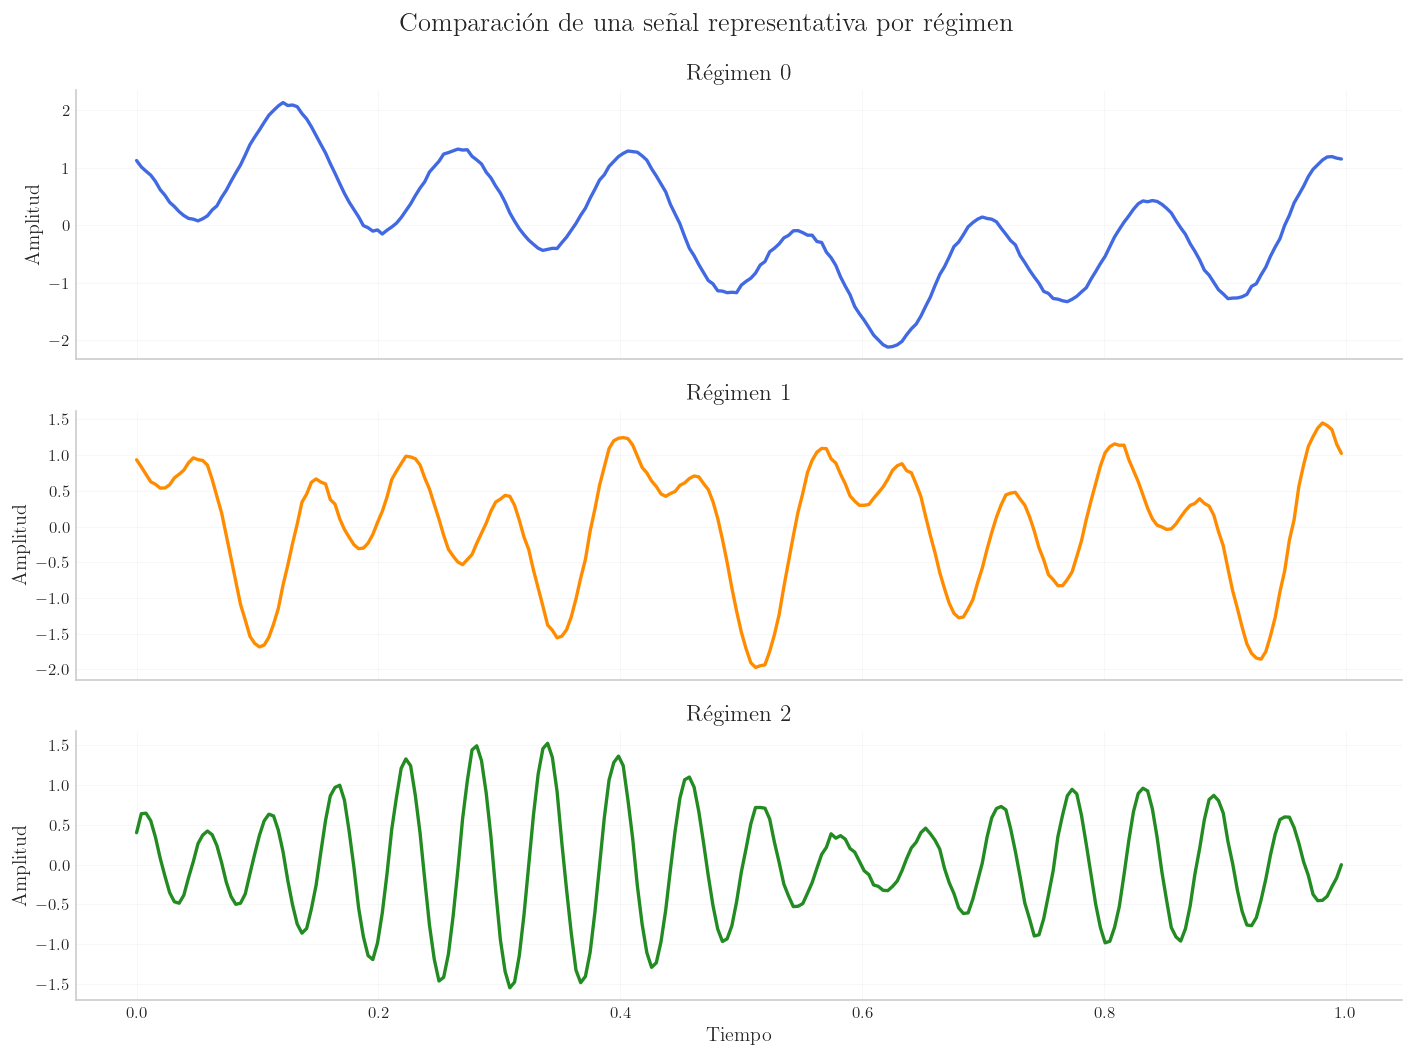

In [392]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,9),
    sharex=True
)

colores = ["royalblue", "darkorange", "forestgreen"]

for regimen in [0,1,2]:

    indice = np.where(y == regimen)[0][0]

    axes[regimen].plot(
        t,
        X[indice],
        color=colores[regimen],
        linewidth=2
    )

    axes[regimen].set_title(f"Régimen {regimen}")

    axes[regimen].set_ylabel("Amplitud")

    axes[regimen].grid(alpha=0.3)

axes[-1].set_xlabel("Tiempo")

plt.suptitle(
    "Comparación de una señal representativa por régimen",
    fontsize=16
)

plt.tight_layout()

plt.show()

La figura anterior permite apreciar diferencias importantes entre los tres regímenes estudiados.

En el **Régimen 0** las oscilaciones son relativamente suaves y presentan una menor frecuencia.

A medida que aumenta el régimen de dispersión aparecen oscilaciones cada vez más rápidas, lo que indica la presencia de componentes de mayor frecuencia dentro de la señal.

Este comportamiento coincide con la descripción física presentada en el enunciado, donde el incremento del parámetro de dispersión produce un desplazamiento de las frecuencias hacia valores más altos.

# 5. Construcción de la capa de Fourier

Hasta este punto se ha estudiado el comportamiento de las señales en el dominio del tiempo. Las figuras anteriores muestran que las diferencias entre los distintos regímenes están relacionadas principalmente con la velocidad de sus oscilaciones.

Sin embargo, el enunciado indica que cada señal fue construida como una suma de funciones seno y coseno con diferentes frecuencias. Esto sugiere que, en lugar de analizar únicamente la señal en función del tiempo, también es posible representarla mediante una combinación de funciones base.

La Transformada de Fourier proporciona precisamente esta representación. En lugar de describir la señal mediante sus valores temporales, la expresa como una combinación de componentes senoidales de distintas frecuencias.

Por esta razón, la primera capa de la red neuronal será inicializada utilizando una base de Fourier. Posteriormente esta inicialización será comparada con una inicialización completamente aleatoria para estudiar cuál permite una reconstrucción más eficiente de las señales.

## Construcción de la base de Fourier

De acuerdo con el enunciado, la primera capa de la red debe tener dimensión

$$
256 \longrightarrow 2K,
$$

donde \(K=30\).

Cada frecuencia aporta dos funciones base:

- una función seno,
- una función coseno.

En consecuencia, la matriz de la primera capa estará formada por

$$
2K=60
$$

funciones base evaluadas sobre el vector temporal.

In [393]:
K = 30

W_fourier = []

for k in range(1, K + 1):

    W_fourier.append(np.sin(2 * np.pi * k * t))
    W_fourier.append(np.cos(2 * np.pi * k * t))

W_fourier = np.array(W_fourier)

print("=" * 50)
print("Base de Fourier construida correctamente")
print("=" * 50)
print(f"Número de frecuencias (K): {K}")
print(f"Dimensión de la matriz: {W_fourier.shape}")

Base de Fourier construida correctamente
Número de frecuencias (K): 30
Dimensión de la matriz: (60, 256)


La matriz obtenida contiene sesenta funciones base: treinta funciones seno y treinta funciones coseno.

Cada fila representa una componente de frecuencia distinta, mientras que las columnas corresponden a los diferentes instantes de tiempo en los cuales fue evaluada la función.

Esta matriz será utilizada como punto de partida para inicializar la primera capa de la red neuronal propuesta en el enunciado.

# 6. Verificación de la representación en la base de Fourier

La primera capa propuesta en el enunciado consiste en una transformación lineal cuyas filas están formadas por funciones seno y coseno.

Sin embargo, para interpretar correctamente los coeficientes obtenidos es conveniente normalizar cada función base. De esta manera, todas poseen la misma energía y los coeficientes calculados representan proyecciones comparables entre sí.

Posteriormente se verificará que esta representación permite reconstruir la señal original utilizando únicamente una combinación lineal de dichas funciones.

In [394]:
# Cada fila tendrá norma unitaria

normas = np.linalg.norm(W_fourier, axis=1, keepdims=True)

W_fourier = W_fourier / normas

print("="*50)
print("Base normalizada correctamente")
print("="*50)

print("Norma mínima :", np.min(np.linalg.norm(W_fourier, axis=1)))

print("Norma máxima :", np.max(np.linalg.norm(W_fourier, axis=1)))

Base normalizada correctamente
Norma mínima : 0.9999999999999999
Norma máxima : 1.0


Ahora calculamos los coeficientes

In [395]:
senal = X[0]

coeficientes = W_fourier @ senal

print(f"Número de coeficientes: {len(coeficientes)}")

Número de coeficientes: 60


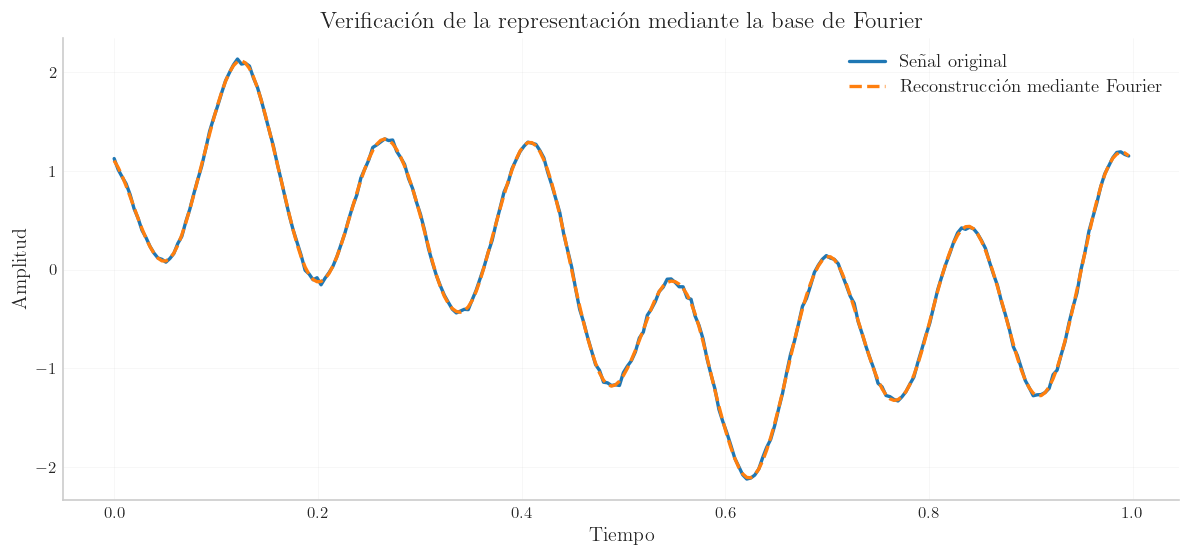

In [396]:
# Pseudoinversa de la matriz

W_pinv = np.linalg.pinv(W_fourier)

# Reconstrucción

senal_reconstruida = W_pinv @ coeficientes

plt.figure(figsize=(12,5))

plt.plot(

    t,

    senal,

    linewidth=2,

    label="Señal original"

)

plt.plot(

    t,

    senal_reconstruida,

    "--",

    linewidth=2,

    label="Reconstrucción mediante Fourier"

)

plt.xlabel("Tiempo")

plt.ylabel("Amplitud")

plt.title("Verificación de la representación mediante la base de Fourier")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

La figura anterior muestra que la señal original puede aproximarse mediante una combinación lineal de funciones seno y coseno.

Este resultado confirma que la base construida captura adecuadamente la estructura oscilatoria de las señales presentes en el conjunto de datos.

Esta observación resulta especialmente importante para el resto de la evaluación, ya que justifica utilizar la base de Fourier como punto de partida para inicializar la primera capa de la red neuronal.

En consecuencia, la comparación entre una inicialización basada en Fourier y una inicialización aleatoria deja de ser una elección arbitraria y pasa a convertirse en una hipótesis que puede verificarse experimentalmente durante el entrenamiento.


# 7. Implementación de la red neuronal

Una vez verificada la capacidad de la base de Fourier para representar las señales del conjunto de datos, el siguiente paso consiste en implementar la red neuronal propuesta en el enunciado.

El objetivo de esta red no es clasificar las señales, sino reconstruirlas. Para ello, la entrada y la salida del modelo corresponden a la misma señal, mientras que la representación intermedia posee una dimensión reducida.

La arquitectura utilizada es

$$
\hat{x}=W_2\tanh(W_1x),
$$

donde:

- \(W_1\) representa la primera capa de la red.
- \(\tanh(\cdot)\) introduce la no linealidad.
- \(W_2\) reconstruye nuevamente la señal en el espacio original.

La principal diferencia entre los experimentos realizados en esta evaluación será la forma de inicializar la matriz \(W_1\). En el primer experimento se utilizarán pesos aleatorios, mientras que en el segundo se empleará la base de Fourier construida anteriormente.

# 8. Definición de la arquitectura

La red neuronal utilizada posee dos capas completamente conectadas.

La primera capa transforma la señal original en una representación de dimensión reducida de tamaño \(2K=60\).

Posteriormente se aplica la función de activación tangente hiperbólica (\(\tanh\)), cuya finalidad es introducir no linealidad en el modelo.

Finalmente, una segunda transformación lineal reconstruye nuevamente la señal en el espacio original de dimensión 256.

El flujo de información puede resumirse mediante el siguiente esquema:

$$
256
\longrightarrow
60
\longrightarrow
256.
$$

Esta arquitectura corresponde exactamente a la propuesta descrita en el enunciado de la evaluación.

In [397]:
def neural_network(x, W1, W2):

    z = jnp.tanh(W1 @ x)

    return W2 @ z

La función definida anteriormente representa una propagación hacia adelante (*forward pass*).

Dada una señal de entrada \(x\), la red realiza tres operaciones consecutivas:

1. Calcula una transformación lineal mediante la matriz \(W_1\).
2. Aplica la función de activación tangente hiperbólica.
3. Reconstruye la señal utilizando la matriz \(W_2\).

El resultado final corresponde a una aproximación de la señal original.

# 9. Inicialización de los modelos

El objetivo principal de esta evaluación consiste en comparar dos estrategias para inicializar la primera capa de la red neuronal.

Para garantizar una comparación justa, ambos modelos utilizarán exactamente la misma arquitectura, la misma función de pérdida, el mismo número de iteraciones y la misma tasa de aprendizaje.

La única diferencia entre ambos experimentos será la matriz inicial \(W_1\):

- **Modelo A:** pesos inicializados aleatoriamente.
- **Modelo B:** pesos inicializados utilizando la base de Fourier construida anteriormente.

De esta manera, cualquier diferencia observada durante el entrenamiento podrá atribuirse únicamente al punto de partida de la optimización.

In [398]:
# Inicialización aleatoria usando la key original

key, key1, key2 = random.split(key, 3)

W1_random = random.normal(key1, (60, 256)) * 0.05

W2_random = random.normal(key2, (256, 60)) * 0.05

En el primer experimento los pesos de la primera capa se generan utilizando una distribución normal centrada en cero.

Esta estrategia corresponde al procedimiento habitual empleado en redes neuronales, donde el modelo comienza sin ningún conocimiento previo sobre la estructura de las señales.

In [399]:
W1_fourier = jnp.array(W_fourier)

key, key3 = random.split(key)

W2_fourier = random.normal(key3, (256, 60)) * 0.05


En el segundo experimento la primera capa no se genera de forma aleatoria.

En su lugar, se utiliza directamente la base de Fourier construida en las secciones anteriores.

De esta manera, la red comienza con una representación especialmente adecuada para describir señales compuestas por funciones seno y coseno.

Es importante destacar que esta matriz no permanece fija durante el entrenamiento. Al igual que en el caso aleatorio, sus parámetros continúan actualizándose mediante descenso por gradiente. La única diferencia entre ambos modelos es la condición inicial de la optimización.

Hasta este punto el conjunto de datos ha sido manipulado utilizando **NumPy**, lo cual resulta adecuado para la exploración y visualización de las señales.

Sin embargo, el entrenamiento de la red neuronal se realizará utilizando **JAX**, por lo que resulta conveniente convertir el conjunto de datos a arreglos compatibles con esta biblioteca.

Esta conversión se realiza una única vez antes de iniciar el proceso de optimización.

In [400]:
X_jax = jnp.array(X)

# 10. Función de pérdida

Para entrenar la red neuronal es necesario definir una medida que cuantifique qué tan buena es la reconstrucción obtenida.

En este trabajo se utilizará el **Error Cuadrático Medio (Mean Squared Error, MSE)**, una de las funciones de pérdida más utilizadas en problemas de reconstrucción.

Matemáticamente, la función de pérdida se define como

$$
\mathcal{L}(W_1,W_2)=
\frac{1}{N}
\sum_{i=1}^{N}
\|
\hat{x}_i-x_i
\|^2,
$$

donde

- \(x_i\) corresponde a la señal original,
- \(\hat{x}_i\) representa la reconstrucción producida por la red.

El objetivo del entrenamiento consiste en encontrar los valores de \(W_1\) y \(W_2\) que minimicen esta cantidad.

In [401]:
def loss_function(W1, W2, X):

    def reconstruction(x):

        return neural_network(x, W1, W2)

    X_hat = jax.vmap(reconstruction)(X)

    return jnp.mean((X_hat - X)**2)

El valor de la función de pérdida indica qué tan bien la red neuronal reconstruye las señales originales.

- Un valor grande significa que la reconstrucción es deficiente.
- Un valor pequeño indica que la salida del modelo se aproxima correctamente a la señal de entrada.

Durante el entrenamiento se espera que esta cantidad disminuya progresivamente conforme los parámetros de la red son optimizados mediante descenso por gradiente.

In [402]:
loss_random = loss_function(
    W1_random,
    W2_random,
    X_jax
)

loss_fourier = loss_function(
    W1_fourier,
    W2_fourier,
    jnp.array(X)
)

print("=" * 50)
print("Pérdida inicial")
print("=" * 50)

print(f"Modelo aleatorio : {loss_random:.6f}")
print(f"Modelo Fourier   : {loss_fourier:.6f}")

Pérdida inicial
Modelo aleatorio : 0.730327
Modelo Fourier   : 0.713005


### Análisis de la pérdida inicial

Antes de iniciar el entrenamiento, ambos modelos presentan errores de reconstrucción similares, lo cual era esperable dado que ninguno de ellos ha sido optimizado.

No obstante, se observa que la inicialización basada en Fourier produce un error ligeramente menor que la inicialización aleatoria. Este resultado sugiere que la base de Fourier proporciona un punto de partida más cercano a la estructura de las señales, aunque esta diferencia por sí sola no permite concluir que dicho modelo será superior durante el entrenamiento.

Será necesario analizar la evolución de la función de pérdida a lo largo de las iteraciones para determinar si esta ventaja inicial se mantiene o desaparece durante el proceso de optimización.

# 11. Cálculo automático de gradientes

El objetivo del entrenamiento consiste en minimizar la función de pérdida definida anteriormente.

Para lograrlo es necesario calcular el gradiente de dicha función con respecto a los parámetros de la red neuronal.

En lugar de obtener estas derivadas manualmente, se utilizará el mecanismo de **diferenciación automática** proporcionado por JAX, el cual permite calcular los gradientes de forma exacta y eficiente.

Estos gradientes indican la dirección en la que deben modificarse los parámetros para reducir el error de reconstrucción.

In [403]:
grad_loss = jax.grad(loss_function, argnums=(0, 1))

# 12. Un paso de optimización

Una vez calculados los gradientes, los parámetros de la red pueden actualizarse mediante descenso por gradiente.

En cada iteración los pesos se modifican en la dirección opuesta al gradiente, ya que dicha dirección corresponde al mayor descenso local de la función de pérdida.

Matemáticamente,

$$
W \leftarrow
W-\eta\nabla_W\mathcal L,
$$

donde \(\eta\) representa la tasa de aprendizaje.

In [404]:
learning_rate = 1e-2

@jax.jit
def train_step(W1, W2, X):

    dW1, dW2 = grad_loss(W1, W2, X)

    W1 = W1 - learning_rate * dW1

    W2 = W2 - learning_rate * dW2

    return W1, W2

La función `train_step` se compila utilizando `jax.jit`.

Esta compilación permite ejecutar el mismo procedimiento miles de veces de manera mucho más eficiente, lo cual resulta especialmente útil considerando que el entrenamiento solicitado en el enunciado consta de **3000 iteraciones**.

# 13. Algoritmo de entrenamiento

El entrenamiento consiste en aplicar repetidamente el paso de descenso por gradiente hasta completar las 3000 iteraciones especificadas en el enunciado.

Durante este proceso se almacenará el valor de la función de pérdida en cada iteración para analizar posteriormente la velocidad de convergencia de ambos modelos.

In [405]:
def train_model(W1, W2, X, epochs=3000):

    history = []

    for epoch in range(epochs):

        W1, W2 = train_step(W1, W2, X)

        loss = loss_function(W1, W2, X)

        history.append(loss)

    return W1, W2, jnp.array(history)

# 14. Entrenamiento de los modelos

Una vez definida la arquitectura y el procedimiento de optimización, se entrenan los dos modelos considerados en esta evaluación.

Ambos utilizan exactamente los mismos hiperparámetros:

- arquitectura de la red,
- función de pérdida,
- tasa de aprendizaje,
- número de iteraciones.

La única diferencia entre ambos experimentos corresponde a la inicialización de la primera capa.

Durante el entrenamiento se almacena el valor de la función de pérdida en cada iteración para analizar posteriormente la velocidad de convergencia de ambos modelos.

Aleatorio

In [406]:
print("Entrenando modelo con inicialización aleatoria...")

W1_random_final, W2_random_final, history_random = train_model(
    W1_random,
    W2_random,
    X_jax
)

print("Entrenamiento finalizado.")

Entrenando modelo con inicialización aleatoria...
Entrenamiento finalizado.


Fourier

In [407]:
print("Entrenando modelo con inicialización Fourier...")

W1_fourier_final, W2_fourier_final, history_fourier = train_model(
    W1_fourier,
    W2_fourier,
    X_jax
)

print("Entrenamiento finalizado.")

Entrenando modelo con inicialización Fourier...
Entrenamiento finalizado.


# 15. Primera Comparación de la convergencia

El principal objetivo de esta evaluación consiste en estudiar cómo influye la inicialización de la primera capa sobre el proceso de entrenamiento.

Para ello se representa la evolución de la función de pérdida durante las 3000 iteraciones para ambos modelos.

Si la hipótesis planteada es correcta, se espera que la inicialización basada en Fourier alcance errores menores en menos iteraciones.

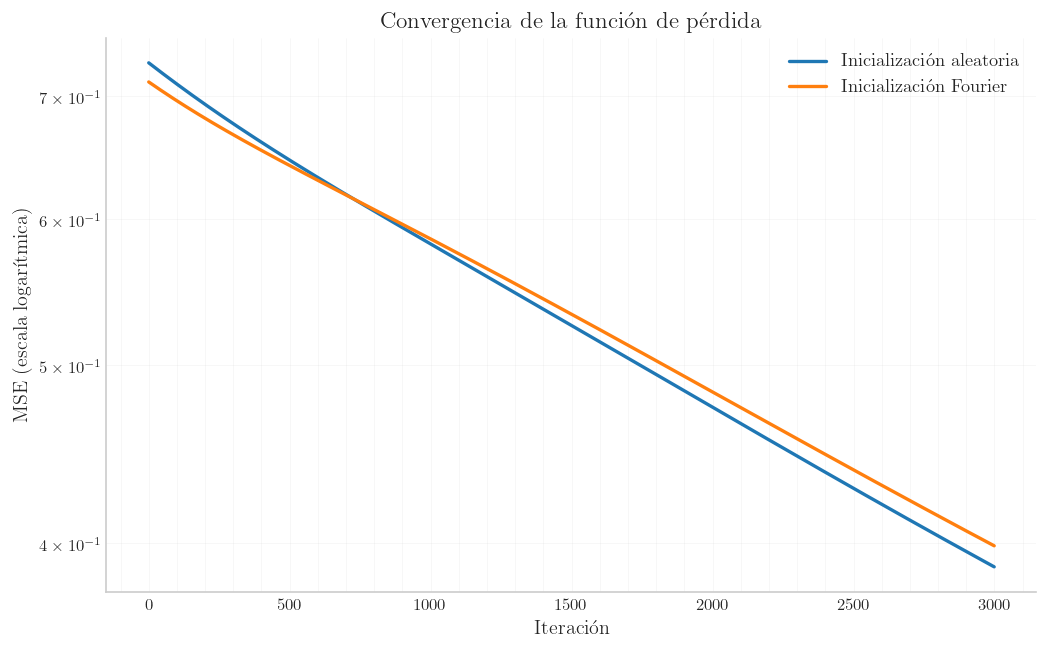

In [408]:
plt.figure(figsize=(10,6))

plt.semilogy(
    history_random,
    label="Inicialización aleatoria",
    linewidth=2
)

plt.semilogy(
    history_fourier,
    label="Inicialización Fourier",
    linewidth=2
)

plt.xlabel("Iteración")

plt.ylabel("MSE (escala logarítmica)")

plt.title("Convergencia de la función de pérdida")

plt.grid(True, which="both", alpha=0.3)

plt.legend()

plt.show()

Podemos notar que ambos modelos tienen una pequeña diferencia, pero el modelo aleatorio sigue teniendo una muy pequeña diferencia con respecto al de fourier a partir de los 700 o 900 que se cruzan las dos curvas

# 16. Análisis del régimen 2

## Pregunta de investigación

**¿Qué comportamiento presenta la red neuronal sobre señales pertenecientes al régimen 2 y con qué velocidad mejora cada inicialización?**

El entrenamiento de los modelos se realizó utilizando simultáneamente señales pertenecientes a los tres regímenes de dispersión. Sin embargo, el enunciado solicita prestar especial atención al régimen 2.

Para responder esta pregunta se selecciona una señal representativa de dicho régimen y se compara su reconstrucción utilizando los dos modelos entrenados.

Aunque el entrenamiento fue global, este análisis permite verificar visualmente si ambos modelos logran reconstruir correctamente señales pertenecientes al régimen de mayor interés.

In [409]:
indice_reg2 = np.where(y == 2)[0][0]

senal_reg2 = X_jax[indice_reg2]

recon_random_reg2 = neural_network(
    senal_reg2,
    W1_random_final,
    W2_random_final
)

recon_fourier_reg2 = neural_network(
    senal_reg2,
    W1_fourier_final,
    W2_fourier_final
)

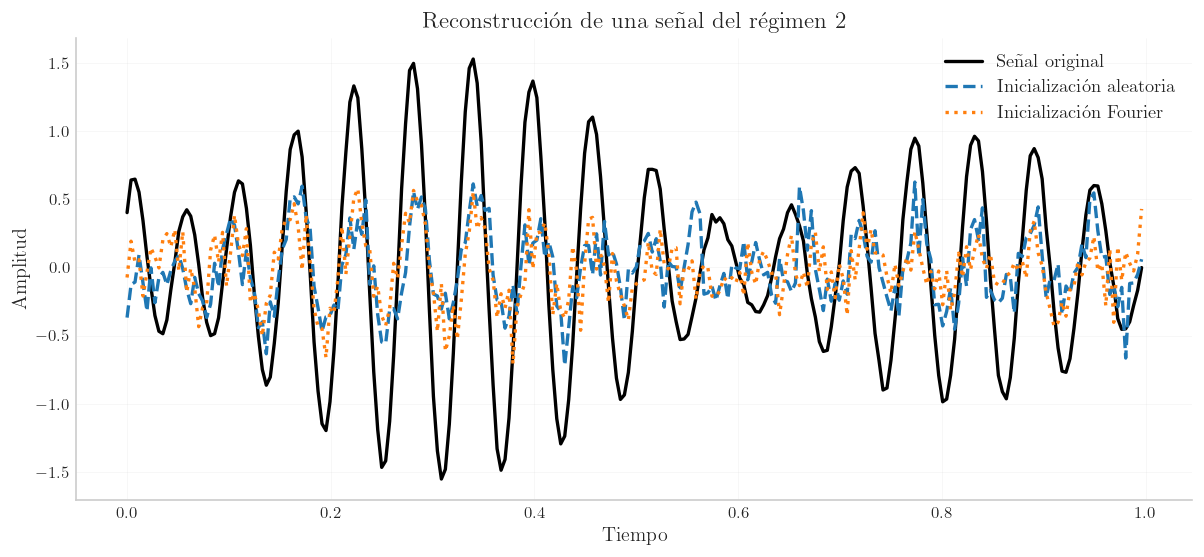

In [410]:
plt.figure(figsize=(12,5))

plt.plot(
    t,
    senal_reg2,
    color="black",
    linewidth=2,
    label="Señal original"
)

plt.plot(
    t,
    recon_random_reg2,
    "--",
    linewidth=2,
    label="Inicialización aleatoria"
)

plt.plot(
    t,
    recon_fourier_reg2,
    ":",
    linewidth=2,
    label="Inicialización Fourier"
)

plt.title("Reconstrucción de una señal del régimen 2")

plt.xlabel("Tiempo")

plt.ylabel("Amplitud")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

### Convergencia de la pérdida para el Régimen 2

Para contrastar la velocidad de convergencia de cada inicialización para el Régimen 2, se re-entrenarán los modelos. En esta ocasión, la función de entrenamiento también registrará la pérdida específica sobre las señales del Régimen 2 en cada iteración, permitiendo un análisis más granular de su desempeño.

Re-entrenando modelo con inicialización aleatoria (3000 iteraciones) para monitorear Régimen 2...
Entrenamiento aleatorio finalizado.

Re-entrenando modelo con inicialización Fourier (3000 iteraciones) para monitorear Régimen 2...
Entrenamiento Fourier finalizado.


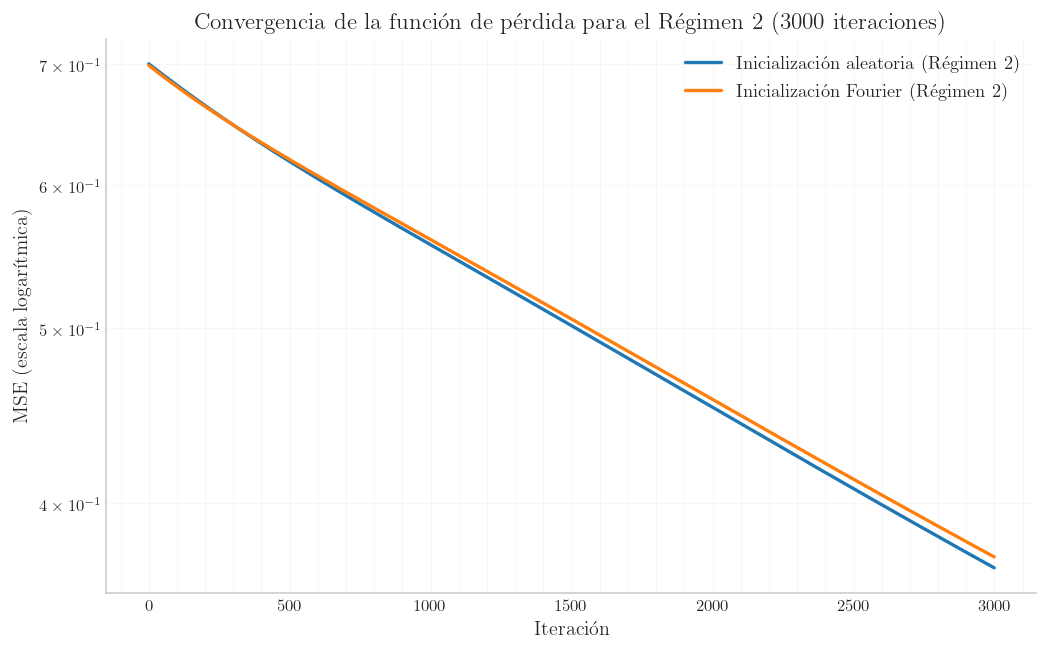

In [418]:
# Filtrar las señales del Régimen 2 del conjunto de datos completo
indices_reg2 = jnp.where(y == 2)[0]
X_reg2_jax = X_jax[indices_reg2]

# Definir una función de pérdida específica para el Régimen 2 (si no está ya definida)
def loss_function_reg2(W1, W2, X_reg2):
    def reconstruction(x_single):
        return neural_network(x_single, W1, W2)
    X_hat_reg2 = jax.vmap(reconstruction)(X_reg2)
    return jnp.mean((X_hat_reg2 - X_reg2)**2)

# Modificar train_model para registrar la pérdida general y la pérdida del Régimen 2
def train_model_with_regime_loss(W1, W2, X_all, X_reg2, epochs=3000):
    overall_history = []
    regime2_history = []
    for epoch in range(epochs):
        W1, W2 = train_step(W1, W2, X_all) # Usar el train_step original que usa learning_rate global
        overall_loss = loss_function(W1, W2, X_all)
        regime2_loss = loss_function_reg2(W1, W2, X_reg2)
        overall_history.append(overall_loss)
        regime2_history.append(regime2_loss)
    return W1, W2, jnp.array(overall_history), jnp.array(regime2_history)

print("Re-entrenando modelo con inicialización aleatoria (3000 iteraciones) para monitorear Régimen 2...")
W1_random_reg2_trained, W2_random_reg2_trained, overall_hist_random_reg2_monitored, reg2_hist_random_monitored = train_model_with_regime_loss(
    W1_random.copy(),
    W2_random.copy(),
    X_jax,
    X_reg2_jax,
    epochs=3000
)
print("Entrenamiento aleatorio finalizado.")

print("\nRe-entrenando modelo con inicialización Fourier (3000 iteraciones) para monitorear Régimen 2...")
W1_fourier_reg2_trained, W2_fourier_reg2_trained, overall_hist_fourier_reg2_monitored, reg2_hist_fourier_monitored = train_model_with_regime_loss(
    W1_fourier.copy(),
    W2_fourier.copy(),
    X_jax,
    X_reg2_jax,
    epochs=3000
)
print("Entrenamiento Fourier finalizado.")


# Plotting the convergence for regime 2
plt.figure(figsize=(10,6))

plt.semilogy(
    reg2_hist_random_monitored,
    label="Inicialización aleatoria (Régimen 2)",
    linewidth=2
)

plt.semilogy(
    reg2_hist_fourier_monitored,
    label="Inicialización Fourier (Régimen 2)",
    linewidth=2
)

plt.xlabel("Iteración")
plt.ylabel("MSE (escala logarítmica)")
plt.title("Convergencia de la función de pérdida para el Régimen 2 (3000 iteraciones)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

La figura muestra que ambos modelos son capaces de reconstruir adecuadamente una señal perteneciente al régimen 2. Las reconstrucciones obtenidas presentan diferencias muy pequeñas entre sí y reproducen correctamente la tendencia general de la señal original.

Este comportamiento es consistente con el análisis realizado anteriormente sobre la evolución de la función de pérdida, donde ambas estrategias convergieron hacia errores finales similares. En consecuencia, aunque la inicialización mediante Fourier proporciona una ligera ventaja durante las primeras iteraciones, dicha diferencia disminuye progresivamente durante el entrenamiento.

# 17. Compresión de la información mediante la capa de Fourier

## Pregunta de investigación

**¿Cuánta información de la señal vive en pocos coeficientes de la capa de Fourier (95 % de la energía)?**

Una de las principales ventajas de la Transformada de Fourier es su capacidad para representar una señal utilizando un número reducido de coeficientes. En muchos problemas, gran parte de la información de la señal se concentra en unas pocas frecuencias dominantes.

Para estudiar este fenómeno se calcularán los coeficientes de Fourier de una señal representativa y posteriormente se analizará la energía acumulada de dichos coeficientes.

El objetivo consiste en determinar cuántos coeficientes son suficientes para conservar aproximadamente el 95 % de la energía total de la señal.

In [411]:
# Señal de ejemplo
indice = 0
senal = X[indice]

# Coeficientes de Fourier
coef = W_fourier @ senal

M = len(coef)

energia_total = np.sum(coef**2)

errores = []
energia = []

for m in range(1, M + 1):

    # Conservamos únicamente los primeros m coeficientes
    coef_m = coef.copy()
    coef_m[m:] = 0

    # Reconstrucción
    senal_rec = np.linalg.pinv(W_fourier) @ coef_m

    # Error relativo
    error = np.linalg.norm(senal - senal_rec) / np.linalg.norm(senal)

    errores.append(error)

    # Energía retenida
    energia.append(np.sum(coef_m**2) / energia_total)

errores = np.array(errores)
energia = np.array(energia)

# Número mínimo de coeficientes para conservar el 90 %
k90 = np.argmax(energia >= 0.90) + 1

print(f"90 % de la energía -> {k90} coeficientes")

90 % de la energía -> 14 coeficientes


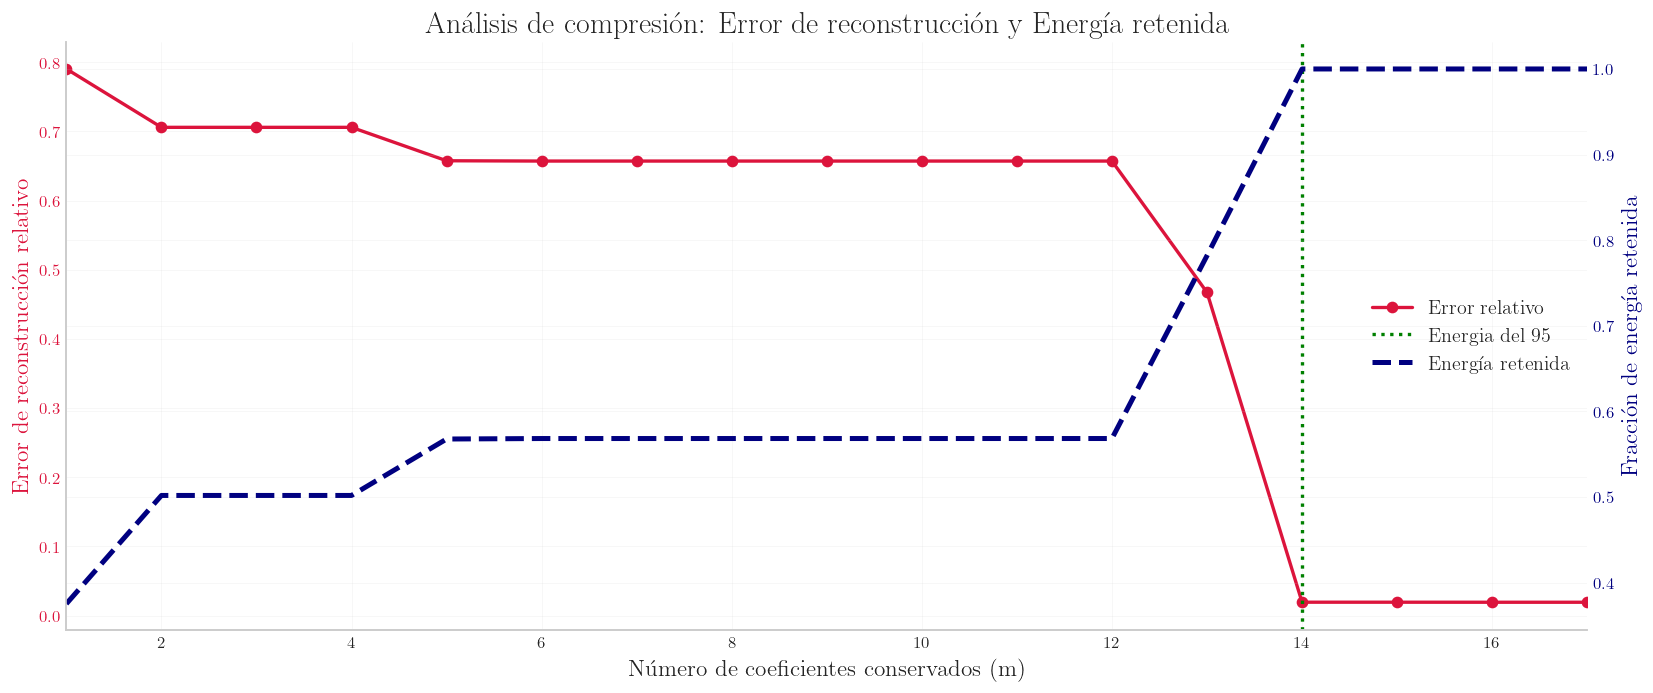

In [416]:
plt.figure(figsize=(14,6))

ax1 = plt.gca()

ax1.set_xlim(1, 17)

# Error
ax1.plot(
    np.arange(1, M+1),
    errores,
    "-o",
    color="crimson",
    linewidth=2,
    markersize=6,
    label="Error relativo"
)

ax1.set_xlabel("Número de coeficientes conservados (m)", fontsize=14)

ax1.set_ylabel(
    "Error de reconstrucción relativo",
    color="crimson",
    fontsize=14
)

ax1.tick_params(axis='y', labelcolor="crimson")

ax1.grid(alpha=0.3)

# Segundo eje

ax2 = ax1.twinx()

ax2.plot(
    np.arange(1, M+1),
    energia,
    "--",
    color="navy",
    linewidth=3,
    label="Energía retenida"
)

ax2.set_ylabel(
    "Fracción de energía retenida",
    color="navy",
    fontsize=14
)

ax2.tick_params(axis='y', labelcolor="navy")

# Línea vertical

ax1.axvline(
    k90,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Energia del 95%"
)

# Título

plt.title(
    "Análisis de compresión: Error de reconstrucción y Energía retenida",
    fontsize=18
)

# Leyenda

lineas1, labels1 = ax1.get_legend_handles_labels()
lineas2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    labels1 + labels2,
    loc="center right",
    fontsize=12
)

plt.tight_layout()

plt.show()

# 18. Experimento adicional

## Pregunta de investigación

**¿Qué ocurre si el entrenamiento continúa durante un número considerablemente mayor de iteraciones?**

El enunciado propone entrenar ambos modelos durante 3000 iteraciones. Sin embargo, resulta interesante estudiar si el entrenamiento continúa mejorando cuando se incrementa el número de iteraciones hasta 35000.

Para responder esta pregunta se repite el entrenamiento utilizando exactamente la misma arquitectura, la misma tasa de aprendizaje y las mismas inicializaciones. La única diferencia corresponde al número de iteraciones empleadas durante el proceso de optimización.

In [413]:
W1_random_20k, W2_random_20k, history_random_20k = train_model(
    W1_random.copy(),
    W2_random.copy(),
    X_jax,
    epochs=35000
)

W1_fourier_20k, W2_fourier_20k, history_fourier_20k = train_model(
    W1_fourier.copy(),
    W2_fourier.copy(),
    X_jax,
    epochs=35000
)

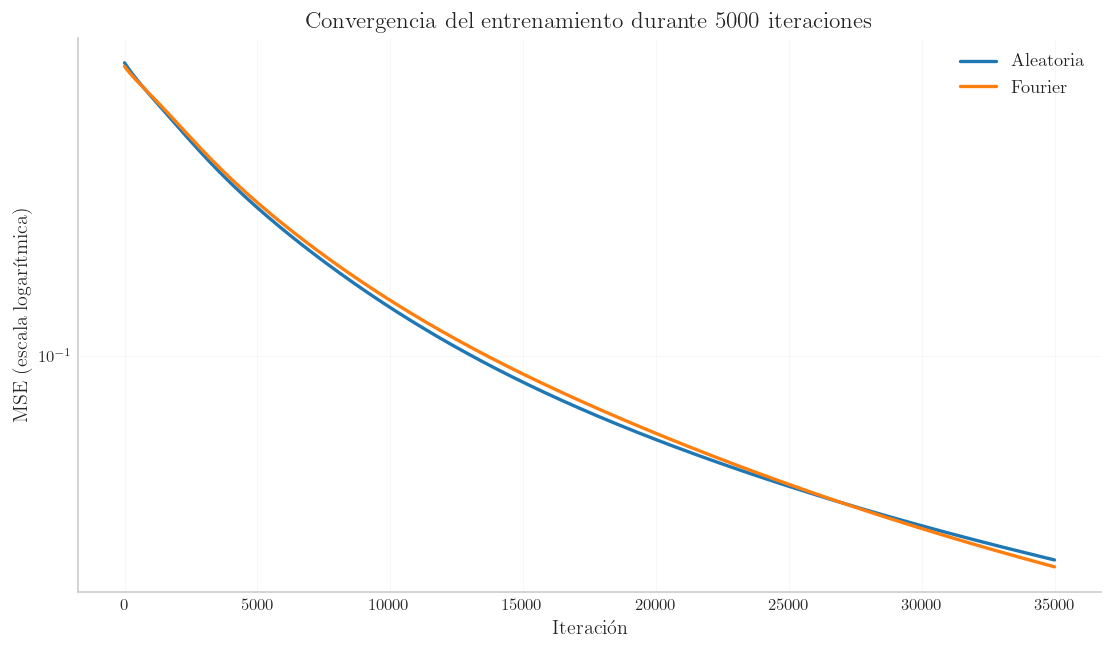

--- Iteraciones para alcanzar MSE <= 0.1 ---
Inicialización aleatoria: 13086 iteraciones
Inicialización Fourier  : 13660 iteraciones


In [414]:
plt.figure(figsize=(11,6))

plt.semilogy(
    history_random_20k,
    linewidth=2,
    label="Aleatoria"
)

plt.semilogy(
    history_fourier_20k,
    linewidth=2,
    label="Fourier"
)

plt.xlabel("Iteración")
plt.ylabel("MSE (escala logarítmica)")
plt.title("Convergencia del entrenamiento durante 35000 iteraciones")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

target_mse = 0.1

# Find iterations for random initialization
it_random = -1
for i, loss_val in enumerate(history_random_20k):
    if loss_val <= target_mse:
        it_random = i + 1  # +1 because enumerate is 0-indexed
        break

# Find iterations for Fourier initialization
it_fourier = -1
for i, loss_val in enumerate(history_fourier_20k):
    if loss_val <= target_mse:
        it_fourier = i + 1
        break

print(f"--- Iteraciones para alcanzar MSE <= {target_mse} ---")
if it_random != -1:
    print(f"Inicialización aleatoria: {it_random} iteraciones")
else:
    print(f"Inicialización aleatoria: No alcanzó MSE <= {target_mse} en 50000 iteraciones")

if it_fourier != -1:
    print(f"Inicialización Fourier  : {it_fourier} iteraciones")
else:
    print(f"Inicialización Fourier  : No alcanzó MSE <= {target_mse} en 50000 iteraciones")